# MLA pure endmembers and block mixtures — `HyFourier` libraries

Loads the **`MLA.shed`** core collection with **hycore** (excluding **Spremberg** boxes), builds:

1. **`hif_mineralogy.fda`** — per-box purest-pixel endmembers (≥ 90% purity; Spremberg and BVR quartz excluded).
2. **`hif_mixtures.fda`** — block-average reflectance with bulk MLA composition in each name.

Both use concatenated **FENIX + FX50 + LWIR** (VNIR–SWIR–MWIR–LWIR) and `notebooks/mineral_families.csv` groups.

Endmember names look like `Quartz100_BVR_Sample40_[12,20]`. Mixture names look like
`BVR_Sample44_Quartz50-Muscovite25-Plagioclase25` (top phases > 1%, up to five ≥ 2.5%).

In [39]:
import os
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt

from hycore import loadShed
import hylite
from hylite import HyLibrary
from hylite.analyse.fourier import HyFourier, FourierArchive, FOURIER_ARCHIVE_EXTENSION

SHED_PATH = '/Users/thiele67/Documents/data/MLA/MLA/MLA.shed'
ISPEC_ROOT = os.path.abspath(os.path.join(os.path.dirname(hylite.__file__), '..', '..', 'ispec'))
FAMILIES_CSV = os.path.join(ISPEC_ROOT, 'notebooks', 'mineral_families.csv')
OUT_DIR = os.path.join(ISPEC_ROOT, 'public', 'libraries')
FDA_PATH = os.path.join(OUT_DIR, 'hif_mineralogy')
MIXTURES_FDA_PATH = os.path.join(OUT_DIR, 'hif_mixtures')
os.makedirs(OUT_DIR, exist_ok=True)

REFLECTANCE_SENSORS = ('FENIX', 'FX50', 'LWIR')  # VNIR+SWIR, MWIR, LWIR
REQUIRED_SENSORS = REFLECTANCE_SENSORS + ('MLA_HSI',)
MIN_PURITY = 0.90
EXCLUDED_PHASES = frozenset({'unknown', 'other', 'porosity'})
EXCLUDED_HOLES = frozenset({'Spremberg'})
QUARTZ_PHASES = frozenset({'quartz', 'qtz'})
EXCLUDED_ENDMEMBER_HOLES = frozenset({'BVR'})
MIN_COMPOSITION_PHASE = 0.01
MIN_REPORTED_ABUNDANCE = 0.025
MAX_REPORTED_PHASES = 5

## 1. Load shed and select boxes

`FENIX` holds VNIR+SWIR in one cube; `FX50` and `LWIR` complete the full range.

**Note:** `Box.getSensors()` reads `sensor_list.npy`, which is often stale in this shed
(`MLA_HSI` was added after the list was written). We therefore check for `{sensor}.hdr`
files on disk — all four are present in most boxes.

In [40]:
def box_has_sensor_hdr(box, sensor):
    """True when `{sensor}.hdr` exists in the box directory."""
    return os.path.exists(os.path.join(box.getDirectory(), f'{sensor}.hdr'))


def box_has_sensors(box, sensors):
    return all(box_has_sensor_hdr(box, sensor) for sensor in sensors)


def hole_name(box):
    parts = box.getFullName().split('/')
    return parts[1] if len(parts) >= 2 else ''


if not os.path.isdir(SHED_PATH):
    raise FileNotFoundError(
        f'MLA shed not found at {SHED_PATH!r}. '
        'Update SHED_PATH to your local MLA.shed directory.'
    )

S = loadShed(SHED_PATH)
shed_dir = S.getDirectory()
if not os.path.isdir(shed_dir):
    raise FileNotFoundError(
        f'hycore resolved shed directory {shed_dir!r}, but it does not exist. '
        f'Check SHED_PATH (got {SHED_PATH!r}).'
    )

print('Shed directory:', shed_dir)
print('Holes:', [h.name for h in S.getHoles()])

boxes = S.getBoxes()
valid_boxes = [
    b for b in boxes
    if box_has_sensors(b, REQUIRED_SENSORS) and hole_name(b) not in EXCLUDED_HOLES
]
listed_boxes = [b for b in boxes if all(s in b.getSensors() for s in REQUIRED_SENSORS)]
print(f'{len(valid_boxes)} / {len(boxes)} boxes have {REQUIRED_SENSORS} (hdr on disk, excl. {sorted(EXCLUDED_HOLES)})')
if not valid_boxes:
    raise RuntimeError(
        'No boxes with coregistered FENIX + FX50 + LWIR + MLA_HSI were found. '
        'Without MLA_HSI abundances there are no mineral phases to rank.'
    )

Shed directory: /Users/thiele67/Documents/data/MLA/MLA/MLA.shed
Holes: ['BVR', 'Bosenbrunn', 'Collinstown', 'Freiberg', 'Geyer', 'Spremberg', 'Stonepark']
181 / 206 boxes have ('FENIX', 'FX50', 'LWIR', 'MLA_HSI') (hdr on disk, excl. ['Spremberg'])


## 2. Helpers — abundances and reflectance

MLA phase layers store **fractional abundances** (0–1). Some ENVI headers still carry the
original MLA `scale factor` (0.015) even though the shed values are already scaled; we only
multiply when raw values look like integer DN (> 1.5).

In [41]:
def is_mineral_phase(phase_name):
    """Skip non-mineral MLA classes (porosity, unclassified buckets, etc.)."""
    return str(phase_name).strip().lower() not in EXCLUDED_PHASES


def is_excluded_endmember(phase_name, box):
    """Endmember-specific exclusions for the pure mineral library."""
    if hole_name(box) in EXCLUDED_ENDMEMBER_HOLES:
        if str(phase_name).strip().lower() in QUARTZ_PHASES:
            return True
    return False


def abundance_cube(mla):
    """Return MLA_HSI abundances as fractional values in [0, 1]."""
    data = mla.data.astype(np.float64)
    scale = float(mla.header.get('scale factor', 1.0))
    if scale != 1.0 and np.nanmax(data) > 1.5:
        data = data * scale
    return data


def align_spectrum(wav, refl, ref_wav):
    """Resample a spectrum onto a reference wavelength grid when needed."""
    wav = np.asarray(wav, dtype=np.float64)
    refl = np.asarray(refl, dtype=np.float64)
    ref_wav = np.asarray(ref_wav, dtype=np.float64)
    if len(wav) == len(ref_wav) and np.allclose(wav, ref_wav, atol=0.15, rtol=0):
        return refl.astype(np.float32)
    return np.interp(ref_wav, wav, refl, left=np.nan, right=np.nan).astype(np.float32)


def reflectance_spectrum(box, y, x):
    """Concatenate FENIX + FX50 + LWIR reflectance at one coregistered pixel."""
    parts, wavs = [], []
    for sensor in REFLECTANCE_SENSORS:
        img = box.get(sensor)
        rsf = float(img.header.get('reflectance scale factor', 1.0))
        spectrum = img.data[y, x].astype(np.float64) / rsf
        parts.append(spectrum)
        wavs.append(np.asarray(img.get_wavelengths(), dtype=np.float64))
    return np.concatenate(parts), np.concatenate(wavs)


def box_sample_id(box):
    """Box label with leading ``b`` prefix removed."""
    box_id = str(box.name).replace(' ', '_')
    if box_id.startswith('b') and len(box_id) > 1:
        box_id = box_id[1:]
    return box_id


def purity_label(phase_name, purity, box, x, y):
    """Build names like Quartz100_BVR_Sample40_[12,20]."""
    return (
        f'{phase_name}{int(round(float(purity) * 100))}_'
        f'{box_sample_id(box)}_[{int(x)},{int(y)}]'
    )


def valid_pixel_mask(box):
    """Pixels with finite reflectance in all sensors (and inside box mask when present)."""
    mla = box.get('MLA_HSI')
    shape = mla.data.shape[:2]
    mask = np.ones(shape, dtype=bool)
    for sensor in REFLECTANCE_SENSORS:
        img = box.get(sensor)
        rsf = float(img.header.get('reflectance scale factor', 1.0))
        reflectance = img.data.astype(np.float64) / rsf
        mask &= np.isfinite(reflectance).all(axis=-1)
    if hasattr(box, 'mask'):
        try:
            box_mask = np.squeeze(box.mask.data)
            if box_mask.ndim == 2 and box_mask.shape == shape:
                mask &= box_mask.astype(bool) if box_mask.dtype == bool else box_mask != 0
        except AttributeError:
            pass
    return mask


def composition_suffix(phase_names, mean_abundances):
    """Bulk composition token, e.g. Quartz50-Muscovite25-Plagioclase25."""
    pairs = []
    for phase_name, abundance in zip(phase_names, mean_abundances):
        if not is_mineral_phase(phase_name) or not np.isfinite(abundance):
            continue
        if abundance <= MIN_COMPOSITION_PHASE:
            continue
        label = str(phase_name).replace(' ', '')
        pairs.append((label, float(abundance)))
    pairs.sort(key=lambda item: -item[1])

    selected = []
    for label, abundance in pairs[:MAX_REPORTED_PHASES]:
        if abundance < MIN_REPORTED_ABUNDANCE:
            break
        selected.append(f'{label}{int(round(abundance * 100))}')
    return '-'.join(selected)


def mixture_label(box, phase_names, mean_abundances):
    suffix = composition_suffix(phase_names, mean_abundances)
    if not suffix:
        return None
    return f'{box_sample_id(box)}_{suffix}'


def box_mean_reflectance(box, pixel_mask):
    """Average concatenated FENIX + FX50 + LWIR over valid pixels."""
    if not pixel_mask.any():
        return None, None

    band_means = []
    wavelengths = []
    for sensor in REFLECTANCE_SENSORS:
        img = box.get(sensor)
        rsf = float(img.header.get('reflectance scale factor', 1.0))
        reflectance = img.data.astype(np.float64) / rsf
        flat = reflectance[pixel_mask].reshape(-1, reflectance.shape[-1])
        band_means.append(flat.mean(axis=0))
        wavelengths.append(np.asarray(img.get_wavelengths(), dtype=np.float64))
    return np.concatenate(band_means), np.concatenate(wavelengths)

## 2b. Mineral families

MLA phase band names (short codes and long Spremberg labels) are mapped to representative
mineral names in `mineral_families.csv`, then grouped by **family** (`silica`, `feldspar`,
`carbonate`, …) like the USGS and ECOSTRESS notebooks.

In [42]:
families = {}
with open(FAMILIES_CSV, 'r', encoding='utf-8') as handle:
    for line in handle:
        line = line.strip()
        if not line or ',' not in line:
            continue
        mineral, family = line.split(',', 1)
        families[mineral.strip().lower()] = family.strip().lower()

print(f'Loaded {len(families)} mineral → family mappings')

# MLA phase label → mineral_families.csv key
MLA_PHASE_TO_MINERAL = {
    'Qtz': 'quartz',
    'Quartz': 'quartz',
    'Plag': 'plagioclase',
    'Plagioclase': 'plagioclase',
    'Ksp': 'feldspar',
    'K-feldspar': 'feldspar',
    'FeChl': 'chlorite',
    'Chl': 'chlorite',
    'Amph': 'amphibole',
    'Ms': 'muscovite',
    'FeMs': 'muscovite',
    'Muscovite': 'muscovite',
    'Kln': 'kaolinite',
    'Kaolinite': 'kaolinite',
    'Illite': 'illite',
    'Sulf': 'sulphide',
    'Sulphate': 'sulphate',
    'Cal': 'calcite',
    'Calcite': 'calcite',
    'DolAnk': 'dolomite',
    'Dolomite': 'dolomite',
    'Ankerite': 'ankerite',
    'Sid': 'siderite',
    'FeOx': 'oxide',
    'TiOx': 'rutile',
    'Ap': 'fluorapatite',
    'Ep': 'epidote',
    'Halite': 'halite',
    'Cu-Sulphide': 'chalcopyrite',
    'Other': None,
    'Unknown': None,
    'Porosity': None,
}


def family_for_phase(phase_name, families_map=families):
    mineral = MLA_PHASE_TO_MINERAL.get(str(phase_name), str(phase_name).lower())
    if not mineral:
        return 'unclassified'
    return families_map.get(mineral.lower(), 'unclassified')

Loaded 212 mineral → family mappings


## 3. Find purest pixel per mineral phase in each box

For every box, take the highest-abundance pixel for each `MLA_HSI` band. The same mineral
phase can therefore appear in multiple boxes (e.g. many `Quartz` entries). Non-mineral classes
(`Unknown`, `Other`, `Porosity`) are skipped.

In [43]:
box_endmembers = []

for box in valid_boxes:
    mla = box.get('MLA_HSI')
    abundances = abundance_cube(mla)
    for band_index, phase in enumerate(mla.get_band_names()):
        phase_name = str(phase)
        if not is_mineral_phase(phase_name) or is_excluded_endmember(phase_name, box):
            continue
        layer = abundances[..., band_index]
        if not np.isfinite(layer).any():
            continue
        flat_index = np.nanargmax(layer)
        purity = float(layer.flat[flat_index])
        y, x = np.unravel_index(flat_index, layer.shape)
        box_endmembers.append({
            'phase': phase_name,
            'purity': purity,
            'box': box,
            'y': y,
            'x': x,
        })

summary = []
for entry in sorted(box_endmembers, key=lambda item: -item['purity']):
    summary.append({
        'phase': entry['phase'],
        'purity_pct': round(entry['purity'] * 100, 1),
        'box': entry['box'].getFullName(),
        'pixel': (entry['y'], entry['x']),
        'keep': entry['purity'] >= MIN_PURITY,
    })

kept = [row for row in summary if row['keep']]
for row in kept:
    print(f"{row['phase']:12s} {row['purity_pct']:5.1f}%  {row['box']}  {row['pixel']}")

print(
    f'\n{len(kept)} / {len(summary)} box-phase endmembers pass the {MIN_PURITY:.0%} purity threshold '
    f'({len(valid_boxes)} boxes scanned)'
)

Lepidolite   100.0%  MLA/BVR/bBVR_Sample27  (np.int64(39), np.int64(5))
Lepidolite   100.0%  MLA/BVR/bBVR_Sample28  (np.int64(11), np.int64(22))
Lepidolite   100.0%  MLA/BVR/bBVR_Sample23  (np.int64(12), np.int64(7))
Lepidolite   100.0%  MLA/BVR/bBVR_Sample21  (np.int64(12), np.int64(8))
Quartz       100.0%  MLA/Bosenbrunn/bBB_Sample15  (np.int64(19), np.int64(38))
Quartz       100.0%  MLA/Geyer/bG18  (np.int64(5), np.int64(4))
Quartz       100.0%  MLA/Geyer/bG9  (np.int64(6), np.int64(4))
Quartz       100.0%  MLA/Geyer/bG6  (np.int64(5), np.int64(2))
Quartz       100.0%  MLA/Geyer/bG3  (np.int64(11), np.int64(19))
Dolomite     100.0%  MLA/Stonepark/bG11B17  (np.int64(4), np.int64(23))
Calcite      100.0%  MLA/Stonepark/bG11B18A  (np.int64(3), np.int64(19))
Calcite      100.0%  MLA/Stonepark/bG11B18b  (np.int64(6), np.int64(31))
Calcite      100.0%  MLA/Stonepark/bTC269  (np.int64(14), np.int64(0))
Dolomite     100.0%  MLA/Stonepark/bG11A3a  (np.int64(0), np.int64(26))
Dolomite     100

## 4. Extract spectra and build `HyLibrary`

In [44]:
names, spectra, wav = [], [], None
group_ids = defaultdict(list)

for entry in sorted(box_endmembers, key=lambda item: -item['purity']):
    phase_name = entry['phase']
    if entry['purity'] < MIN_PURITY or is_excluded_endmember(phase_name, entry['box']):
        continue
    spectrum, wavelengths = reflectance_spectrum(entry['box'], entry['y'], entry['x'])
    if not np.isfinite(spectrum).all():
        print(f'skip {phase_name} in {entry["box"].getFullName()}: non-finite reflectance')
        continue
    if wav is None:
        wav = wavelengths
    else:
        spectrum = align_spectrum(wavelengths, spectrum, wav)
    if not np.isfinite(spectrum).all():
        print(f'skip {phase_name} in {entry["box"].getFullName()}: non-finite reflectance after alignment')
        continue

    label = purity_label(phase_name, entry['purity'], entry['box'], entry['x'], entry['y'])
    sample_index = len(names)
    names.append(label)
    spectra.append(spectrum)
    family = family_for_phase(phase_name)
    group_ids[family].append(sample_index)

if not names:
    raise RuntimeError('No endmember spectra met the purity threshold.')

data = np.stack(spectra, axis=0)[:, None, :]
library = HyLibrary(data, lab=names, wav=wav)
for family, indices in sorted(group_ids.items()):
    library.add_group(family, indices)

print(f'HyLibrary: {library.sample_count()} samples, {library.band_count()} bands')
print(f'Groups: {sorted(library.get_groups())}')
print(f'Wavelength range: {wav[0]:.1f} – {wav[-1]:.1f} nm')

skip Calcite in MLA/Collinstown/bT16: non-finite reflectance
skip Pyrite in MLA/Stonepark/bG11A9: non-finite reflectance
skip Calcite in MLA/Stonepark/bG11A8: non-finite reflectance
skip Dolomite in MLA/Stonepark/bG11B19A: non-finite reflectance
HyLibrary: 115 samples, 861 bands
Groups: ['carbonate', 'evaporite', 'feldspar', 'silica', 'sulphide', 'unclassified', 'white-mica']
Wavelength range: 378.2 – 12320.2 nm


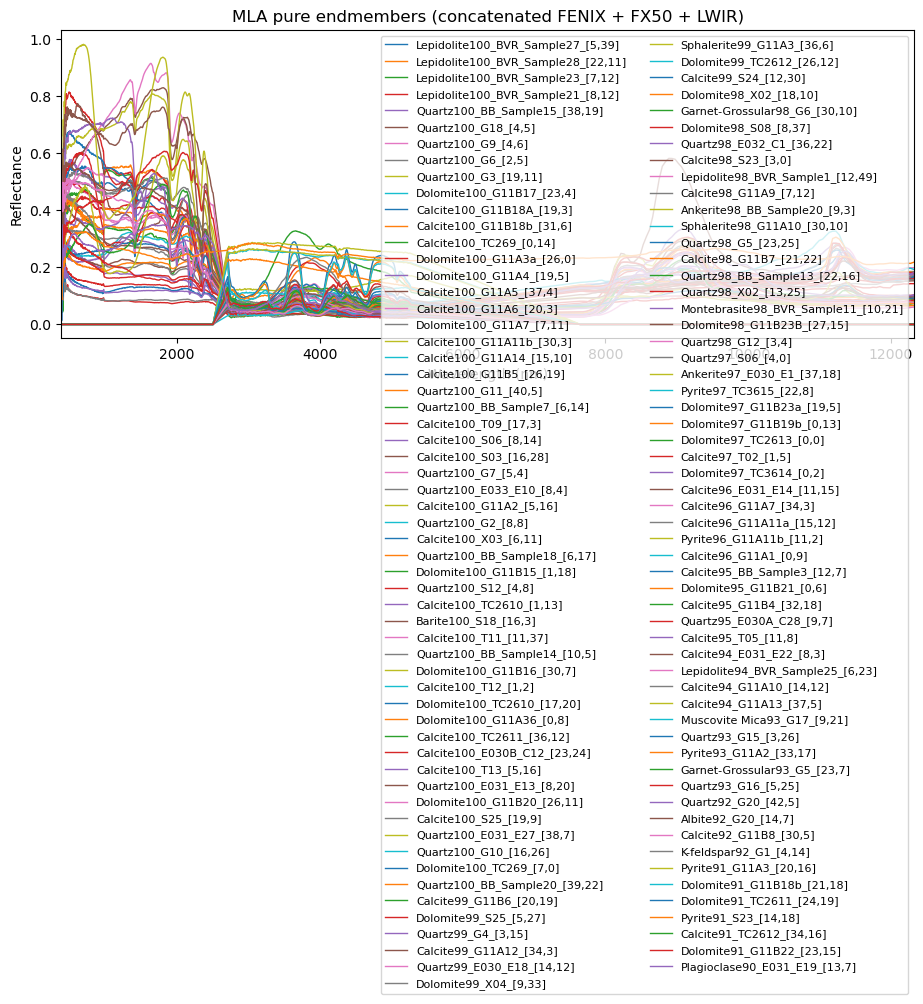

In [45]:
fig, ax = plt.subplots(figsize=(11, 4))
for name, spectrum in zip(names, spectra):
    ax.plot(wav, spectrum, lw=1.0, label=name)
ax.set_xlim(wav[0], wav[-1])
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Reflectance')
ax.set_title('MLA pure endmembers (concatenated FENIX + FX50 + LWIR)')
ax.legend(fontsize=8, ncol=2, loc='upper right')
fig.tight_layout()

## 5. Build and save `hif_mineralogy` archive

In [46]:
hyfourier = HyFourier(library, padding='cosine', max_freq=0.25, vb=True)
hyfourier.precomputeExtrema(kde_sigma=10.0, vb=True)

archive = FourierArchive()
archive['hif-mineralogy'] = hyfourier
archive.save(FDA_PATH)

print('Saved', FDA_PATH + FOURIER_ARCHIVE_EXTENSION)
print('HyFourier shape:', hyfourier.data.shape)

Saved /Users/thiele67/Documents/python/ispec/public/libraries/hif_mineralogy.fda
HyFourier shape: (115, 215, 2)


## 6. Block-average mixture library

For each box, average reflectance over all valid (finite, unmasked) pixels and derive a bulk
composition label from mean MLA abundances. Report up to **five** mineral phases that are
**> 1%** on average, stopping when abundance falls below **2.5%**.

In [47]:
mixture_names, mixture_spectra, mixture_wav = [], [], None
mixture_group_ids = defaultdict(list)

for box in valid_boxes:
    pixel_mask = valid_pixel_mask(box)
    if not pixel_mask.any():
        continue

    mla = box.get('MLA_HSI')
    abundances = abundance_cube(mla)
    phase_names = [str(phase) for phase in mla.get_band_names()]
    mean_abundances = [
        float(np.nanmean(abundances[pixel_mask, band_index]))
        for band_index in range(len(phase_names))
    ]

    label = mixture_label(box, phase_names, mean_abundances)
    if label is None:
        continue

    spectrum, wavelengths = box_mean_reflectance(box, pixel_mask)
    if spectrum is None or not np.isfinite(spectrum).all():
        print(f'skip {box.getFullName()}: non-finite block-average reflectance')
        continue

    if mixture_wav is None:
        mixture_wav = wavelengths
    else:
        spectrum = align_spectrum(wavelengths, spectrum, mixture_wav)
    if not np.isfinite(spectrum).all():
        print(f'skip {label}: non-finite reflectance after alignment')
        continue

    sample_index = len(mixture_names)
    mixture_names.append(label)
    mixture_spectra.append(spectrum)
    mixture_group_ids[hole_name(box)].append(sample_index)

if not mixture_names:
    raise RuntimeError('No block-average mixture spectra met the composition labelling rules.')

mixture_data = np.stack(mixture_spectra, axis=0)[:, None, :]
mixture_library = HyLibrary(mixture_data, lab=mixture_names, wav=mixture_wav)
for group_name, indices in sorted(mixture_group_ids.items()):
    mixture_library.add_group(group_name, indices)

print(f'Mixture HyLibrary: {mixture_library.sample_count()} samples, {mixture_library.band_count()} bands')
print(f'Hole groups: {sorted(mixture_library.get_groups())}')
print('Examples:', mixture_names[:5])


Mixture HyLibrary: 181 samples, 861 bands
Hole groups: ['BVR', 'Bosenbrunn', 'Collinstown', 'Freiberg', 'Geyer', 'Stonepark']
Examples: ['BVR_Sample1_Quartz42-Muscovite25-Lepidolite12-K-feldspar8', 'BVR_Sample26_Albite33-Quartz20-Lepidolite20-K-feldspar6-Topaz4', 'BVR_Sample27_Quartz43-Muscovite27-Lepidolite16', 'BVR_Sample28_Quartz46-Muscovite27-Lepidolite16', 'BVR_Sample29_Albite42-Quartz21-Lepidolite14-K-feldspar6-Topaz3']


In [48]:
mixture_hyfourier = HyFourier(mixture_library, padding='cosine', max_freq=0.25, vb=True)
mixture_hyfourier.precomputeExtrema(kde_sigma=10.0, vb=True)

mixtures_archive = FourierArchive()
mixtures_archive['hif-mixtures'] = mixture_hyfourier
mixtures_archive.save(MIXTURES_FDA_PATH)

print('Saved', MIXTURES_FDA_PATH + FOURIER_ARCHIVE_EXTENSION)
print('HyFourier shape:', mixture_hyfourier.data.shape)


Saved /Users/thiele67/Documents/python/ispec/public/libraries/hif_mixtures.fda
HyFourier shape: (181, 215, 2)


## 7. Smoke-test search


In [49]:
query = '2200 | 2300'
print('hif_mineralogy:')
result_names, result_scores = archive.search(query, confidence=10.0, n_result=5)
for name, score in zip(result_names, result_scores):
    print(f'  {score:0.3f}  {name}')

print('\nhif_mixtures:')
mix_names, mix_scores = mixtures_archive.search(query, confidence=10.0, n_result=5)
for name, score in zip(mix_names, mix_scores):
    print(f'  {score:0.3f}  {name}')


hif_mineralogy:
  0.074  (hif-mineralogy) [white-mica] Lepidolite100_BVR_Sample28_[22,11]
  0.023  (hif-mineralogy) [carbonate] Dolomite99_S25_[5,27]
  0.070  (hif-mineralogy) [white-mica] Lepidolite100_BVR_Sample27_[5,39]
  0.015  (hif-mineralogy) [unclassified] Ankerite97_E030_E1_[37,18]
  0.069  (hif-mineralogy) [white-mica] Lepidolite100_BVR_Sample21_[8,12]

hif_mixtures:
  0.070  (hif-mixtures) [Bosenbrunn] BB_Sample17_MuscoviteMica31-Quartz21-ChamositeChl12-Illite12-MuscoviteMica(FeMg)11
  0.009  (hif-mixtures) [Collinstown] S25_Calcite49-Dolomite48
  0.067  (hif-mixtures) [Freiberg] E033_E24_Quartz24-Kaolinite22-Siderite14-Ankerite12
  0.009  (hif-mixtures) [Bosenbrunn] BB_Sample5_ActinoliteAM27-Calcite21-Albite21-ChamositeChl13-Titanite6
  0.067  (hif-mixtures) [Freiberg] E031_E27_Quartz59-FeMuscovite12-Chlorite6-Muscovite6
